In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
# Check if a GPU is available and set the device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

# Download training data (50,000 images) and test data (10,000)
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True,
    download=True, transform=transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False,
    download=True, transform=transform
)


train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=False
)

classes = ('plane','car','bird','cat','deer',
           'dog','frog','horse','ship','truck')
print(f'Train size: {len(train_dataset)}, Test size: {len(test_dataset)}')

100%|██████████| 170M/170M [00:04<00:00, 34.3MB/s]


Train size: 50000, Test size: 10000


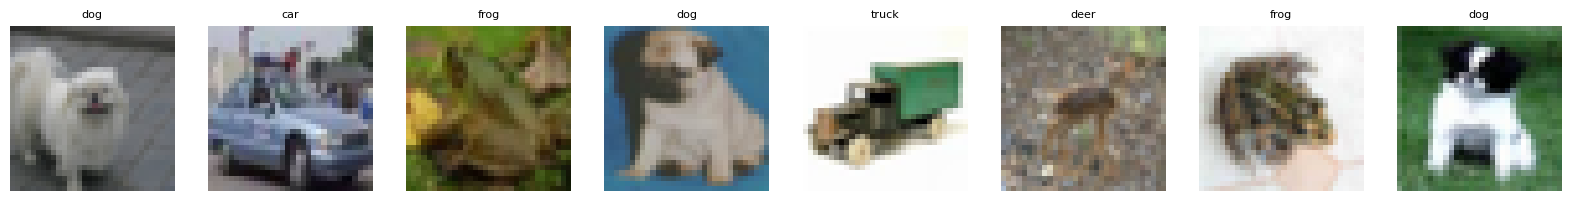

In [4]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i in range(8):
    img = images[i].numpy().transpose(1, 2, 0)
    img = img * np.array([0.247,0.243,0.261]) + np.array([0.491,0.482,0.446])
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(classes[labels[i]], fontsize=8)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # BLOCK 1: detect edges and simple shapes
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        # BLOCK 2: detect more complex patterns
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        # BLOCK 3: detect high-level features (ears, wheels, etc.)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.pool    = nn.MaxPool2d(2, 2)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

        # After 3 pools: 32 → 16 → 8 → 4, with 128 filters = 128*4*4
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)   # 10 output classes

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 4 * 4)    # flatten
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)
Parameters: 620,810


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

Epoch [1/20] Loss: 1.3933
Epoch [2/20] Loss: 1.0509
Epoch [3/20] Loss: 0.9128
Epoch [4/20] Loss: 0.8225
Epoch [5/20] Loss: 0.7535
Epoch [6/20] Loss: 0.6969
Epoch [7/20] Loss: 0.6422
Epoch [8/20] Loss: 0.5876
Epoch [9/20] Loss: 0.5442
Epoch [10/20] Loss: 0.5051
Epoch [11/20] Loss: 0.3793
Epoch [12/20] Loss: 0.3410
Epoch [13/20] Loss: 0.3237
Epoch [14/20] Loss: 0.3110
Epoch [15/20] Loss: 0.2946
Epoch [16/20] Loss: 0.2847
Epoch [17/20] Loss: 0.2749
Epoch [18/20] Loss: 0.2655
Epoch [19/20] Loss: 0.2558
Epoch [20/20] Loss: 0.2452
Training complete!


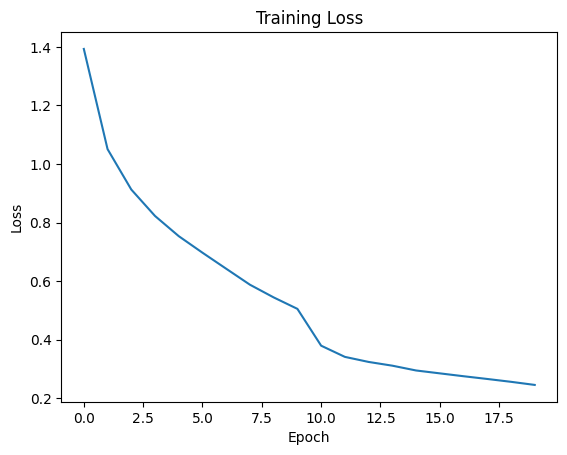

In [9]:
train_losses = []
NUM_EPOCHS = 20

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()        # clear old gradients
        outputs = model(images)      # forward pass
        loss = criterion(outputs, labels)
        loss.backward()              # backpropagation
        optimizer.step()             # update weights

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step()
    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] Loss: {avg_loss:.4f}')

print('Training complete!')

# Plot loss curve
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.show()

In [11]:
torch.save(model.state_dict(), 'cifar10_cnn.pth')

In [12]:
model.eval()   # switches off dropout for evaluation
correct = 0
total = 0

with torch.no_grad():   # don't compute gradients during testing
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')

Test Accuracy: 81.41%


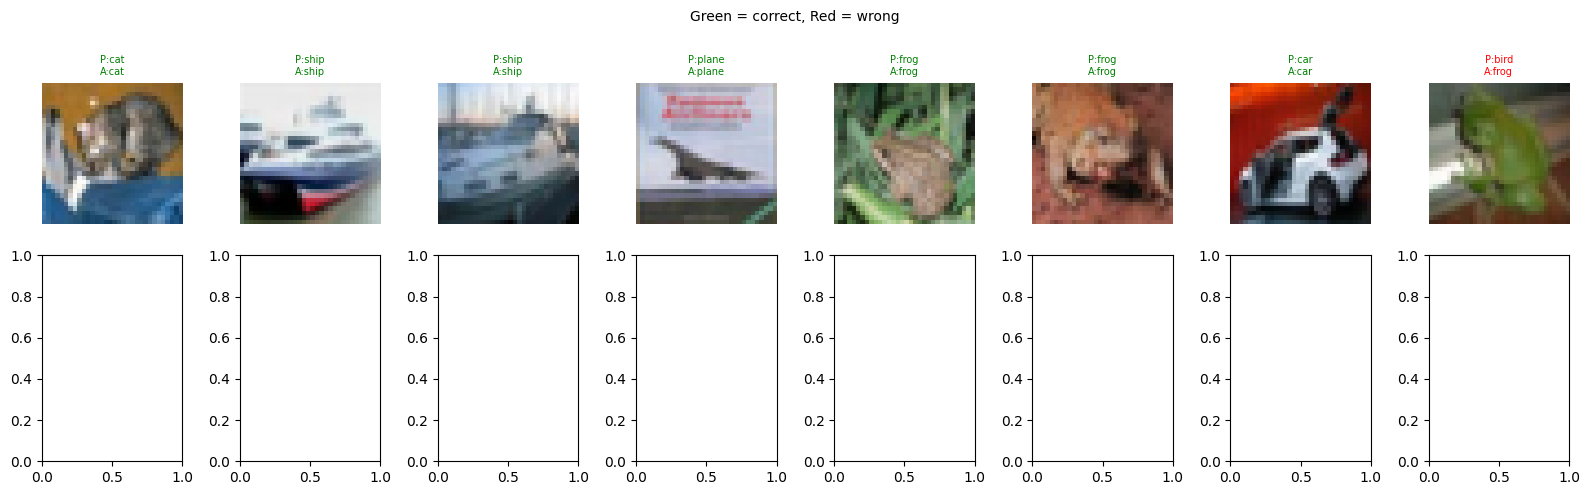

In [13]:
dataiter = iter(test_loader)
images, labels = next(dataiter)
outputs = model(images.to(device))
_, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i in range(8):
    img = images[i].numpy().transpose(1, 2, 0)
    img = img * np.array([0.247,0.243,0.261]) + np.array([0.491,0.482,0.446])
    img = np.clip(img, 0, 1)
    axes[0,i].imshow(img)
    axes[0,i].axis('off')
    color = 'green' if predicted[i]==labels[i] else 'red'
    axes[0,i].set_title(
        f'P:{classes[predicted[i]]}\nA:{classes[labels[i]]}',
        fontsize=7, color=color
    )
plt.suptitle('Green = correct, Red = wrong', fontsize=10)
plt.tight_layout()
plt.show()